# Fourier Analysis - Error Bar

## Configuração
Edite apenas esta célula para adicionar/remover partículas ou frequências.

In [39]:
import matplotlib.pyplot as plt
import numpy as np
np.seterr('warn')

from aux_functions import make_fitting_func, fit_curve, shorten_points, sort_experiments_by_freq
from treament_tcspc_data import extract_data_info_from_path, fetch_data_filenames, get_fund_freq_and_amp, get_modulus_angle_unc

In [40]:
filenames_all = fetch_data_filenames("./sandbox")

In [41]:
exc_data_npy = [extract_data_info_from_path(data_path_npy) for data_path_npy in filenames_all if ("step" in data_path_npy) and (".npy" in data_path_npy) and ("exc_laser" in data_path_npy)]
data_txt = [extract_data_info_from_path(data_path_txt) for data_path_txt in filenames_all if ("step" in data_path_txt) and (".txt" in data_path_txt) and ("p10_" in data_path_txt)]
data_npy = [extract_data_info_from_path(data_path_npy) for data_path_npy in filenames_all if ("step" in data_path_npy) and (".npy" in data_path_npy) and ("p10_" in data_path_npy)]

In [42]:
freq_list = [1, 10, 100, 1000, 10000]
filtered_data = [d for d in data_npy if d["freq"] in freq_list]
filtered_exc_data = [d for d in exc_data_npy if d["freq"] in freq_list]
exc_data = sort_experiments_by_freq(filtered_exc_data)

## Plots

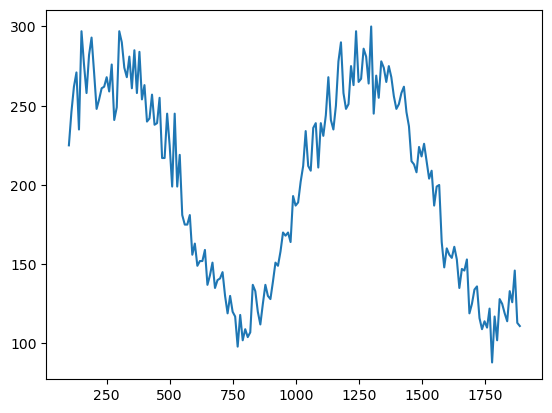

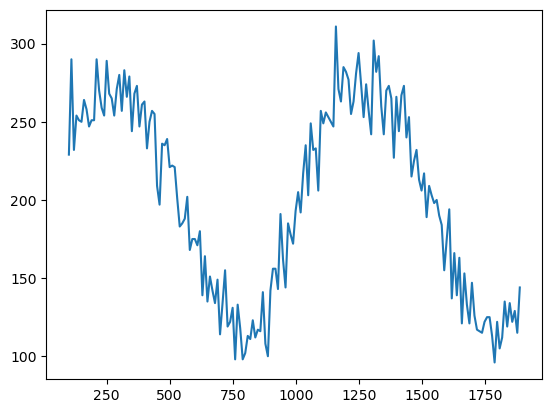

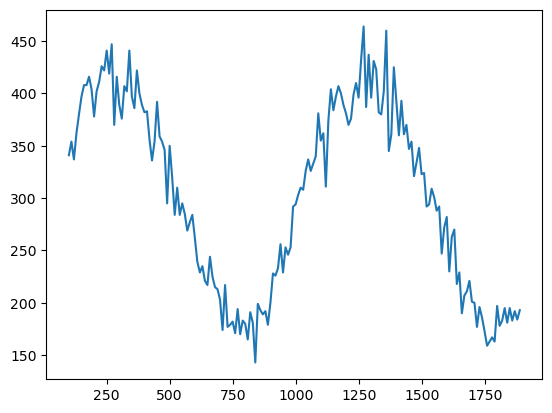

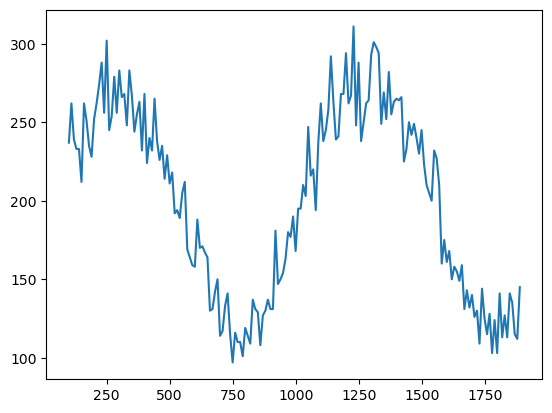

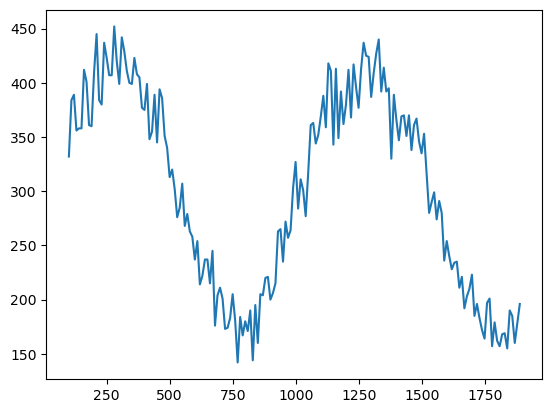

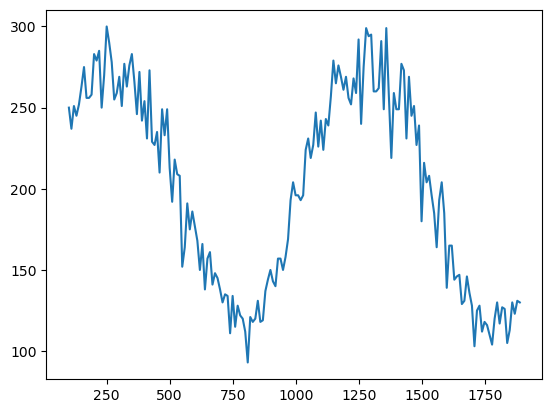

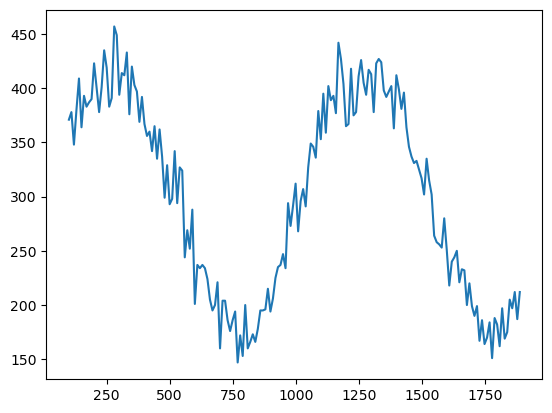

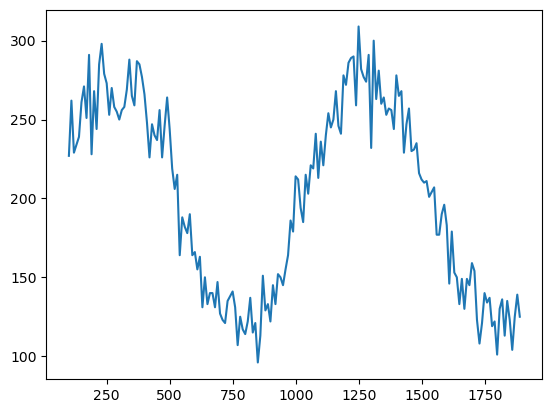

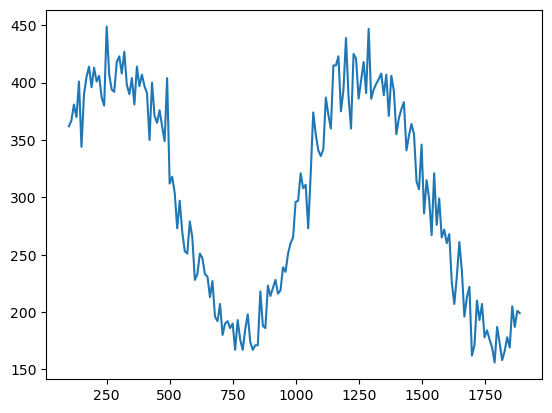

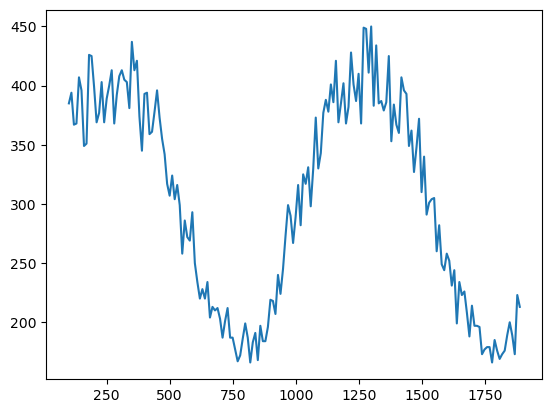

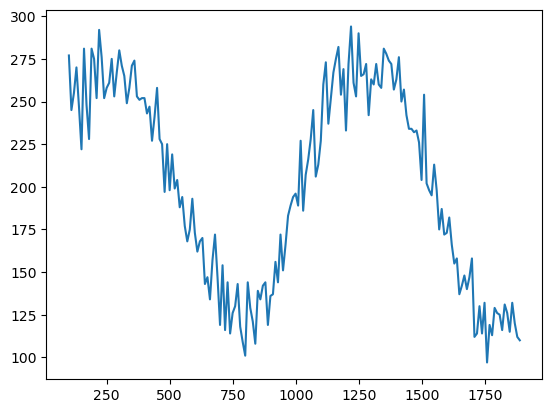

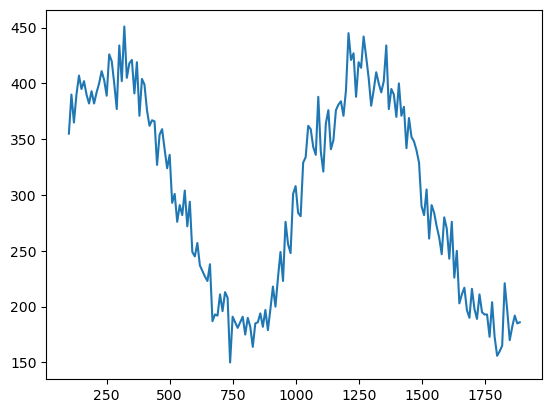

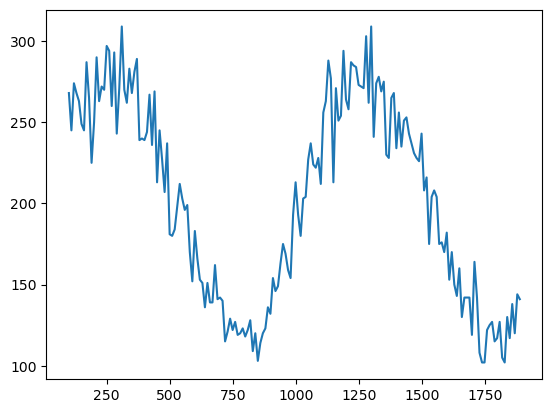

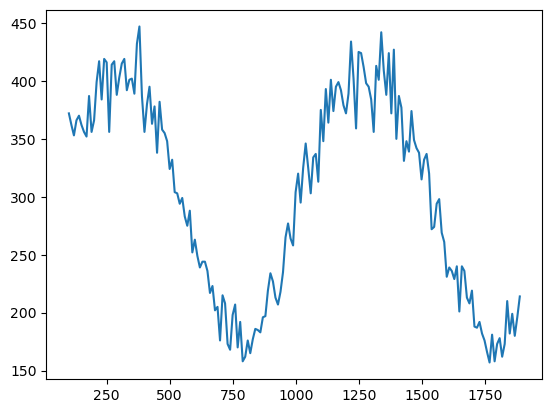

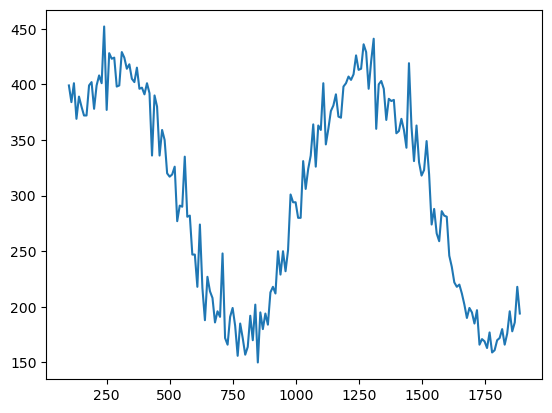

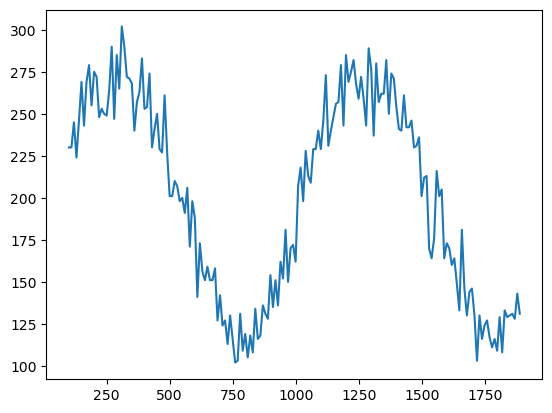

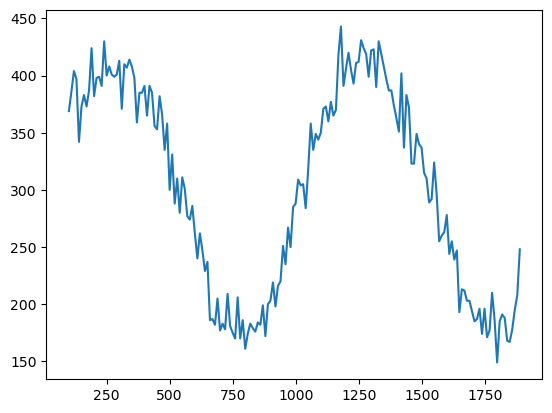

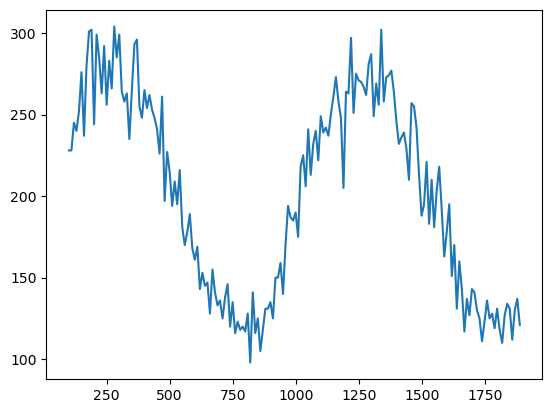

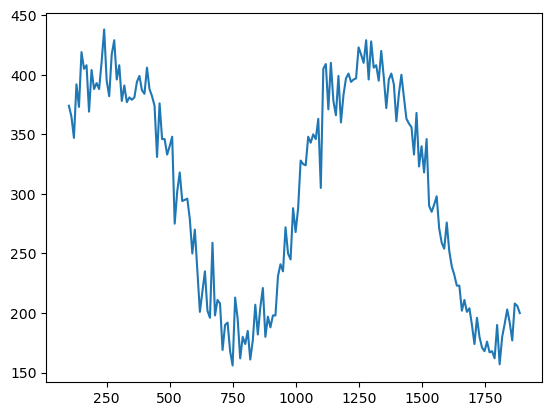

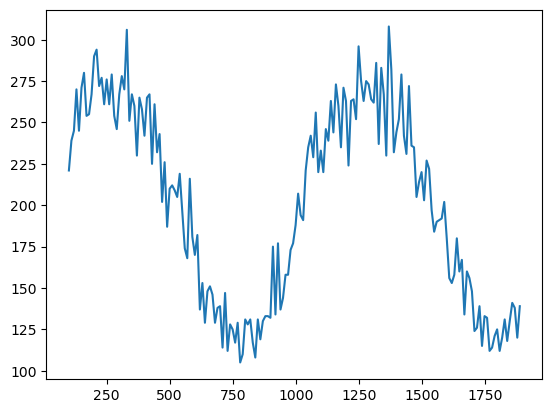

In [43]:
## Populate luminescence FFT info

lum_fund_freq_info = []

for idx, dic in enumerate(filtered_data):
    # if idx != 3:
    #     continue
    lum_fund_freq_info.append({
        "freq": dic["freq"],
        "fft_data": []
    })

    for rep_idx, rep in enumerate(dic["data"]):
        xs_lum, ys_lum = shorten_points(
            np.column_stack((rep[:,0], rep[:,1])), 
            # num_points_off=(10, 20)
            )
        if dic["freq"]==1000: 
            plt.plot(xs_lum, ys_lum)
            plt.show()
        
        lum_fund_freq_info[-1]["fft_data"].append(
            get_fund_freq_and_amp(xs_lum, ys_lum)
            )
    
    fft_data_arr = np.array(lum_fund_freq_info[-1]["fft_data"])

    fund_freq_mean = fft_data_arr[:,0].real.mean()
    fund_freq_std = fft_data_arr[:,0].real.std()

    rp_fund_amp_mean = fft_data_arr[:,1].real.mean()
    rp_fund_amp_std = fft_data_arr[:,1].real.std()
    ip_fund_amp_mean = fft_data_arr[:,1].imag.mean()
    ip_fund_amp_std = fft_data_arr[:,1].imag.std()
    
    lum_fund_freq_info[-1]["fund_freq_mean"] = fund_freq_mean
    lum_fund_freq_info[-1]["fund_freq_std"] = fund_freq_std
    # means -> (<xf>, <yf>)
    lum_fund_freq_info[-1]["fund_amp_mean"] = (rp_fund_amp_mean, ip_fund_amp_mean)
    # uncertainties -> (delat_xf, delta_yf)
    lum_fund_freq_info[-1]["fund_amp_std"] = (rp_fund_amp_std, ip_fund_amp_std)
    # xf = <xf> +- delta_xf

#Propagating the uncertainties
for el in lum_fund_freq_info:
    x, y = el["fund_amp_mean"] 
    dx, dy = el["fund_amp_std"]
    m, th = get_modulus_angle_unc(x, dx, y, dy)
    
    el["angle"] = th
    el["modulus"] = m


In [44]:
## Populate laser FFT info

exc_fund_freq_info = []

for idx, dic in enumerate(exc_data):
    # if idx != 3:
    #     continue
    exc_fund_freq_info.append({
        "freq": dic["freq"],
        "fft_data": []
    })

    for rep_idx, rep in enumerate(dic["data"]):
        xs_exc, ys_exc = shorten_points(
            np.column_stack((rep[:,0], rep[:,1])), 
            # num_points_off=(10, 20)
            )
        
        exc_fund_freq_info[-1]["fft_data"].append(
            get_fund_freq_and_amp(xs_exc, ys_exc)
            )
    
    fft_data_arr = np.array(exc_fund_freq_info[-1]["fft_data"])

    fund_freq_mean = fft_data_arr[:,0].real.mean()
    fund_freq_std = fft_data_arr[:,0].real.std()

    rp_fund_amp_mean = fft_data_arr[:,1].real.mean()
    rp_fund_amp_std = fft_data_arr[:,1].real.std()
    ip_fund_amp_mean = fft_data_arr[:,1].imag.mean()
    ip_fund_amp_std = fft_data_arr[:,1].imag.std()
    
    exc_fund_freq_info[-1]["fund_freq_mean"] = fund_freq_mean
    exc_fund_freq_info[-1]["fund_freq_std"] = fund_freq_std
    # means -> (<xf>, <yf>)
    exc_fund_freq_info[-1]["fund_amp_mean"] = (rp_fund_amp_mean, ip_fund_amp_mean)
    # uncertainties -> (delat_xf, delta_yf)
    exc_fund_freq_info[-1]["fund_amp_std"] = (rp_fund_amp_std, ip_fund_amp_std)
    # xf = <xf> +- delta_xf

#Propagating the uncertainties
for el in exc_fund_freq_info:
    x, y = el["fund_amp_mean"] 
    dx, dy = el["fund_amp_std"]
    m, th = get_modulus_angle_unc(x, dx, y, dy)
    
    el["angle"] = th
    el["modulus"] = m

In [45]:
lum_fund_freq_info[0]["angle"], exc_fund_freq_info[0]["angle"]

(-1.2682115932291818+/-0.009244040194799328,
 -1.2407750539276399+/-0.006061540471094193)

In [46]:
if False:
    xs_laser, ys_laser = shorten_points(
        np.column_stack((np.array(exc_data[idx]["data"])[0,:,0], np.array(exc_data[idx]["data"])[:,:,1].mean(axis=0)))
        )
    xs_lum, ys_lum = shorten_points(
        np.column_stack((np.array(filtered_data[idx]["data"])[0,:,0], np.array(filtered_data[idx]["data"])[:,:,1].mean(axis=0)))
        )
    # plot_time_and_freq_domain(xs_lum, ys_lum, ys_laser)    
    fund_freq_info.append({
        "freq": freq,
        "laser_fund_freq_dict": get_fund_freq_and_amp(xs_laser, ys_laser),
        "lum_fund_freq_dict": get_fund_freq_and_amp(xs_lum, ys_lum),
        })
    
if False:
    fig, ax1 = plt.subplots()
    ax1.plot(xs_laser*(1e-6), ys_laser/np.max(ys_laser), color="tab:red", label="laser")
    ax1.set_xlabel("Time ($\mu$s)")
    ax1.set_ylabel("Intensity Laser (a.u.)")
    ax1.legend(loc="upper left")
    ax2 = ax1.twinx()
    ax2.plot(xs_lum*(1e-6), ys_lum/np.max(ys_lum), color="tab:green", label="lum")
    ax2.set_ylabel("Intensity Luminescence (a.u.)")
    ax2.legend()
    plt.title(f"Time Domain - {freq} Hz")
    plt.show()
#-------

## Time domain plots

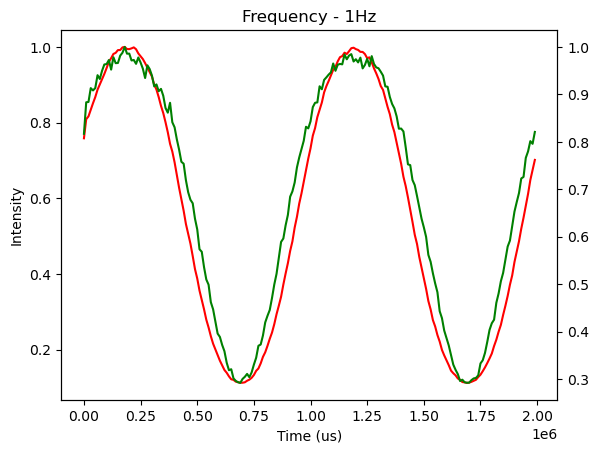

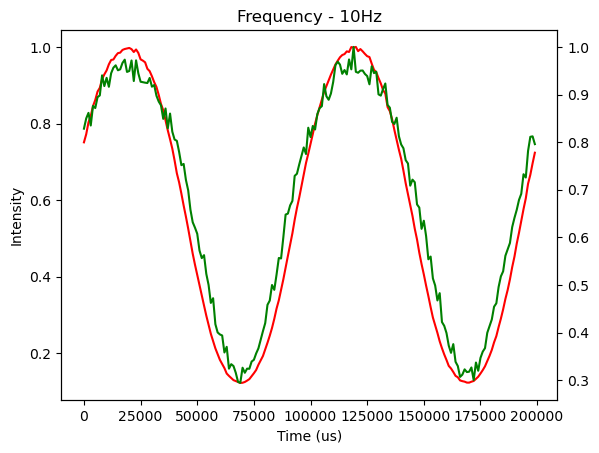

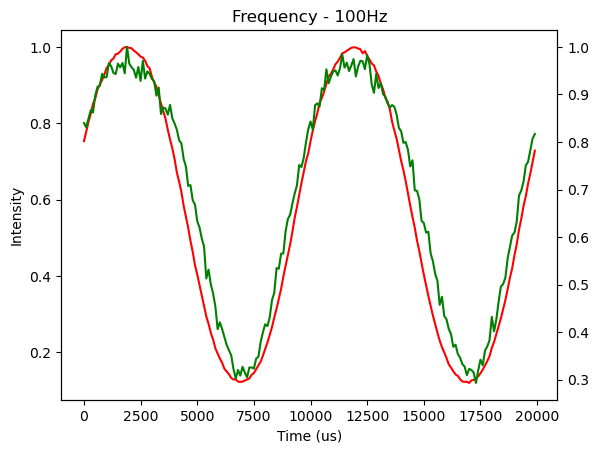

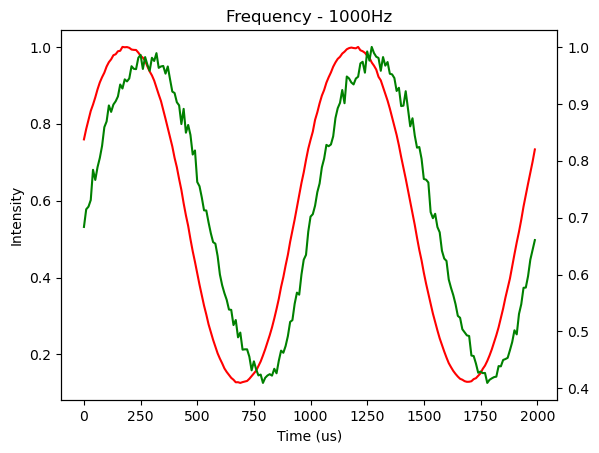

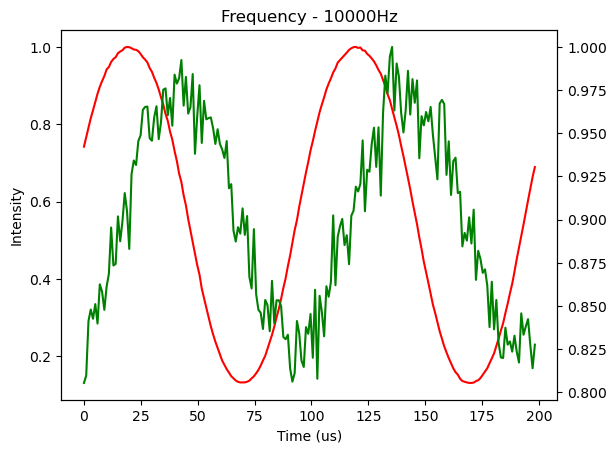

In [47]:
for idx, freq in enumerate(freq_list):
    xs_exc = np.array(exc_data[idx]["data"])[:,:200,:1].mean(axis=0)
    ys_exc = np.array(exc_data[idx]["data"])[:,:200,1:2].mean(axis=0)

    xs_lum = np.array(filtered_data[idx]["data"])[:,:200,:1].mean(axis=0)
    ys_lum = np.array(filtered_data[idx]["data"])[:,:200,1:2].mean(axis=0)

    fig, axs = plt.subplots()

    axs.plot(xs_exc, ys_exc/ys_exc.max(), label="exc", color="red")
    axs.set_xlabel("Time (us)")
    axs.set_ylabel("Intensity")

    axs2 = axs.twinx()
    axs2.plot(xs_lum, ys_lum/ys_lum.max(), label="lum", color="green")
    plt.title(f"Frequency - {exc_data[idx]["freq"]}Hz")
    # plt.legend()

    plt.show()

## Phase difference vs frequency

In [48]:
pd_via_fft = []
for idx, freq in enumerate(freq_list):
    lum_p = lum_fund_freq_info[idx]["angle"].nominal_value
    exc_p = exc_fund_freq_info[idx]["angle"].nominal_value
    pd_via_fft.append(lum_p - exc_p)

pd_via_fft = np.degrees(np.unwrap(pd_via_fft))


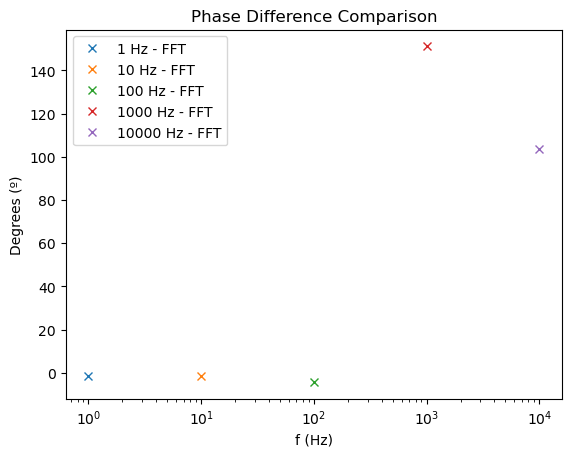

In [49]:
for idx, el in enumerate(pd_via_fft):
    # color = colors[idx % len(colors)]
    freq, phase =  freq_list[idx] , el
    
    plt.errorbar(
        freq,
        phase,
        # yerr=error,  # error_bars[idx]["mean_std"],
        label=f"{freq} Hz - FFT",
        fmt="x",
        capsize=5,
        # color=color,
    )

plt.xscale("log")
plt.title("Phase Difference Comparison")
plt.ylabel("Degrees (º)")
plt.xlabel("f (Hz)")
plt.legend()
plt.show()